# **Scaler Analayis**

---

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler

CLEAN_DATASET = 'car_details_basic'

df = pd.read_csv(f'../data/clean/{CLEAN_DATASET}.csv')

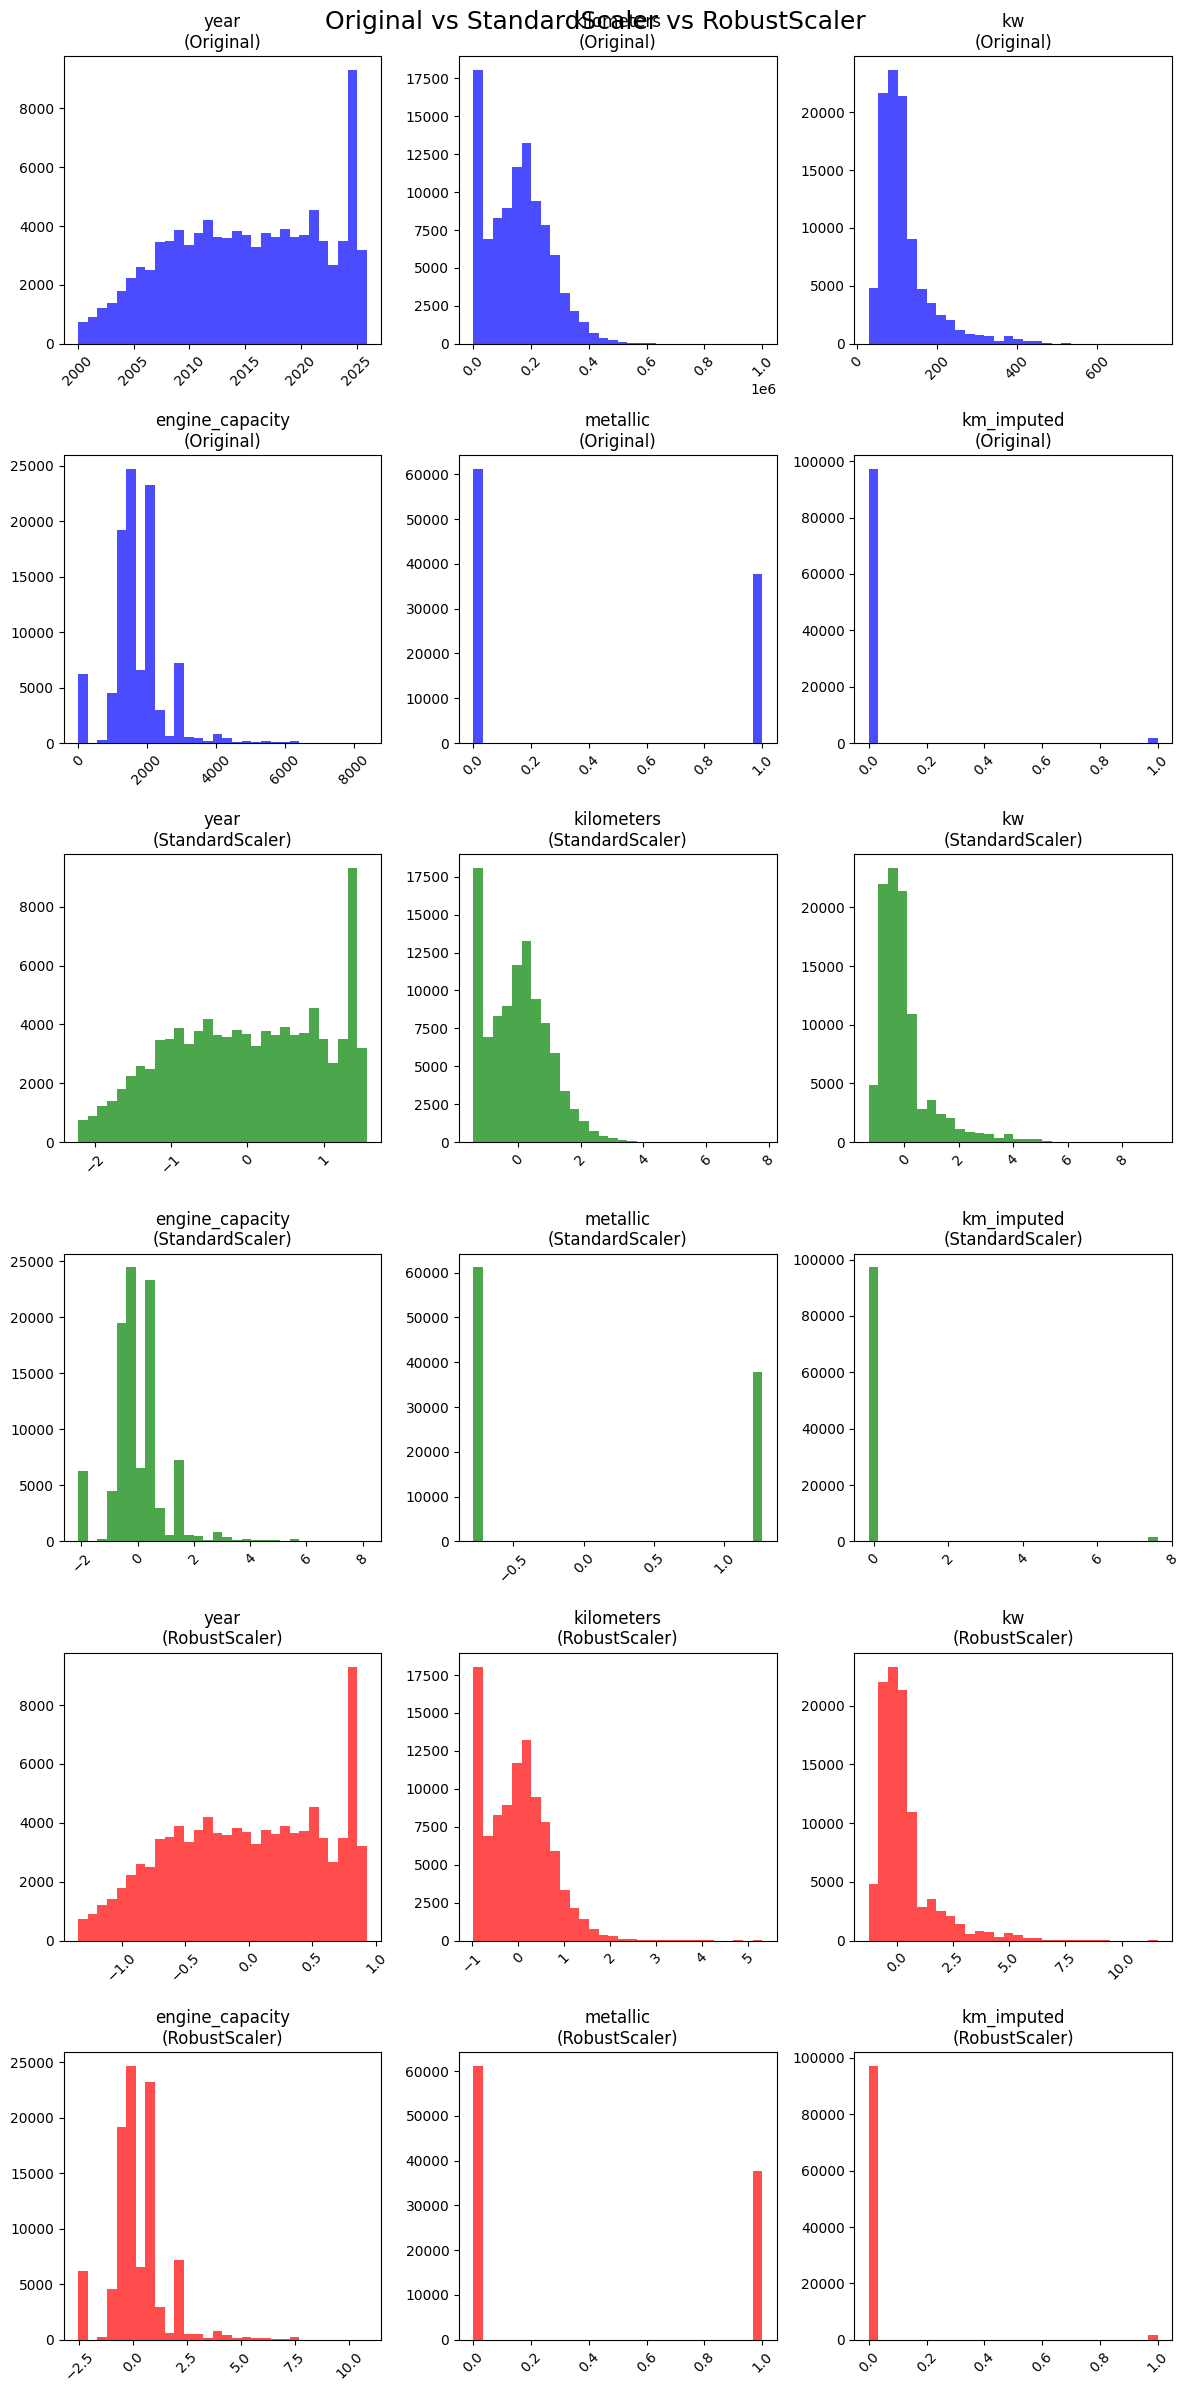

In [ ]:
numerical_features = [
   'year', 'kilometers', 'kw','engine_capacity', 'metallic', 'km_imputed'
]

sample_df = df[numerical_features]

standard_scaler = StandardScaler()
standard_scaled_data = standard_scaler.fit_transform(sample_df)
standard_scaled_df = pd.DataFrame(standard_scaled_data, columns=numerical_features)

robust_scaler = RobustScaler()
robust_scaled_data = robust_scaler.fit_transform(sample_df)
robust_scaled_df = pd.DataFrame(robust_scaled_data, columns=numerical_features)

# Create a 6x3 grid
fig, axes = plt.subplots(6, 3, figsize=(12, 24))

for i, feature in enumerate(numerical_features):
    row, col = divmod(i, 3)

    # --- Original
    axes[row, col].hist(sample_df[feature], bins=30, alpha=0.7, color='blue')
    axes[row, col].set_title(f'{feature}\n(Original)', fontsize=12)
    axes[row, col].tick_params(axis='x', rotation=45, labelsize=10)

    # --- StandardScaler
    axes[row+2, col].hist(standard_scaled_df[feature], bins=30, alpha=0.7, color='green')
    axes[row+2, col].set_title(f'{feature}\n(StandardScaler)', fontsize=12)
    axes[row+2, col].tick_params(axis='x', rotation=45, labelsize=10)

    # --- RobustScaler
    axes[row+4, col].hist(robust_scaled_df[feature], bins=30, alpha=0.7, color='red')
    axes[row+4, col].set_title(f'{feature}\n(RobustScaler)', fontsize=12)
    axes[row+4, col].tick_params(axis='x', rotation=45, labelsize=10)

plt.tight_layout()
plt.suptitle('Original vs StandardScaler vs RobustScaler', fontsize=18, y=0.995)
plt.show()